In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

from unifigs.figures import RatioPlot
from NNMFit.utilities import load_pickle


### Load Bestfit Histograms (from step0_2_1_reco_space_graphs.ipynb)

In [2]:
step0_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/philipp/step0_2_1/graphs"
scan_names = [
    "hese_spectrum_bestfit_13year_round3",
    "hese_spectrum_bestfit_13year_round3_NoSystematics",
]


In [3]:
histogram_collection = {}
for scan_name in scan_names:
    print(scan_name)
    histogram_collection[scan_name] = {}
    data_hist_path = glob.glob(os.path.join(step0_path, scan_name, "Data_Histogram.pickle"))
    if len(data_hist_path) != 1:
        raise ValueError(f"Expected exactly one Data_Histogram.pickle for {scan_name}, found {len(data_hist_path)}")
    histogram_collection[scan_name]["data"] = load_pickle(data_hist_path[0])

    mc_hist_path = glob.glob(os.path.join(step0_path, scan_name, "MC_Histogram*.pickle"))
    if len(mc_hist_path) < 1:
        raise ValueError(f"Expected at least one MC_Histogram.pickle for {scan_name}, found {len(mc_hist_path)}")
    histogram_collection[scan_name]["mc"] = load_pickle(mc_hist_path[0])


hese_spectrum_bestfit_13year_round3
hese_spectrum_bestfit_13year_round3_NoSystematics


### Meta Information for binning and plotting

In [4]:
dimensions = {
    "IC86_pass2_SnowStorm_FTP_HESE_Cascades": {
        "reco_energy": {
            "binning_key": "reco_energy",
            "log_x": True,
            "log_y": True,
            "x_label": r"$E_{\mathrm{Monopod}}$ [GeV]",
            "y_label": "Expected Rate [Hz]",
            "sum_axes": 1,
            "flip": False,
            "ylims": [1e-11, 3e-4],
        },
        "reco_zenith": {
            "binning_key": "reco_zenith",
            "log_x": False,
            "log_y": True,
            "x_label": r"$\cos(\theta_{\mathrm{SplineMPE}})$",
            "y_label": "Expected Rate [Hz]",
            "sum_axes": 0,
            "flip": True,
            "ylims": None,
        },
    },
    "IC86_pass2_SnowStorm_FTP_HESE_Tracks": {
        "reco_energy": {
            "binning_key": "reco_energy",
            "log_x": True,
            "log_y": True,
            "x_label": r"$E_{\mathrm{Monopod}}$ [GeV]",
            "y_label": "Expected Rate [Hz]",
            "sum_axes": 1,
            "flip": False,
            "ylims": None,
        },
        "reco_zenith": {
            "binning_key": "reco_zenith",
            "log_x": False,
            "log_y": True,
            "x_label": r"$\cos(\theta_{\mathrm{Monopod}})$",
            "y_label": "Expected Rate [Hz]",
            "sum_axes": 0,
            "flip": True,
            "ylims": None,
        },
    },
}


In [5]:
binning_dict = {}

binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"] = {}
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_energy"] = np.geomspace(10**4.778, 10**7.1, 24)
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_zenith"] = np.linspace(-1, 1, 11)

binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Tracks"] = {}
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Tracks"]["reco_energy"] = np.geomspace(10**4.778, 10**7.1, 24)
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Tracks"]["reco_zenith"] = np.linspace(-1, 1, 11)


### Plotting Functions

In [6]:
def get_histogram_projection(
    histogram, det_config, binning_dict, projected_dimension, flip=False
):
    reshape_shape = (
        binning_dict[det_config]["reco_energy"].shape[0] - 1,
        binning_dict[det_config]["reco_zenith"].shape[0] - 1,
    )
    sum_axis = dimensions[det_config][projected_dimension]["sum_axes"]
    h = np.sum(np.reshape(histogram, reshape_shape), axis=sum_axis)
    if flip:
        h = np.flip(h, axis=0)
    return h


def plot_histogram(
    ax, histogram_dict, det_config, plot_dimension, fit_dimension, binning_dict,
    draw_style="stairs", label="Label", color="black", **kwargs,
):
    histogram = get_histogram_projection(
        histogram_dict["histograms"][det_config], det_config, binning_dict,
        projected_dimension=plot_dimension,
        flip=dimensions[det_config][plot_dimension]["flip"],
    )
    if "fluctuations" not in histogram_dict or histogram_dict["fluctuations"] is None:
        fluctuations = np.sqrt(histogram)
    else:
        fluctuations = get_histogram_projection(
            np.sqrt(histogram_dict["fluctuations"][det_config]), det_config, binning_dict,
            projected_dimension=plot_dimension,
            flip=dimensions[det_config][plot_dimension]["flip"],
        )
    if draw_style == "stairs":
        ax.stairs(histogram, binning_dict[det_config][plot_dimension],
                  label=label, color=color, **kwargs)
    elif draw_style == "errors":
        bin_centers = (
            np.diff(binning_dict[det_config][plot_dimension]) / 2
            + binning_dict[det_config][plot_dimension][:-1]
        )
        ax.errorbar(bin_centers, histogram, yerr=fluctuations,
                    fmt=".", label=label, color=color, **kwargs)


def calc_ratio_err(numerator, denominator, err_numerator, err_denominator):
    ratio = numerator / denominator
    ratio_err = ratio * np.sqrt(
        (err_numerator / numerator)**2 + (err_denominator / denominator)**2
    )
    return ratio, ratio_err


def plot_ratio(
    ax, mc_dict, data_dict, det_config, plot_dimension, binning_dict,
    include_mc_err=True, label="Ratio", color="black", capsize=2,
    markeredgecolor="black", **kwargs,
):
    reshape_shape = (
        binning_dict[det_config]["reco_energy"].shape[0] - 1,
        binning_dict[det_config]["reco_zenith"].shape[0] - 1,
    )
    sum_axis = dimensions[det_config][plot_dimension]["sum_axes"]
    flip     = dimensions[det_config][plot_dimension]["flip"]

    mc_h   = np.sum(np.reshape(mc_dict["histograms"][det_config],   reshape_shape), axis=sum_axis)
    data_h = np.sum(np.reshape(data_dict["histograms"][det_config], reshape_shape), axis=sum_axis)
    if include_mc_err:
        mc_ssq = np.sum(np.reshape(mc_dict["fluctuations"][det_config], reshape_shape), axis=sum_axis)

    if flip:
        mc_h   = np.flip(mc_h)
        data_h = np.flip(data_h)
        if include_mc_err:
            mc_ssq = np.flip(mc_ssq)

    if include_mc_err:
        ratio, ratio_err = calc_ratio_err(
            data_h, mc_h, np.sqrt(data_h), np.sqrt(mc_ssq)
        )
    else:
        ratio, ratio_err = calc_ratio_err(
            data_h, mc_h, np.sqrt(data_h), np.zeros_like(mc_h)
        )

    bin_centers = (
        np.diff(binning_dict[det_config][plot_dimension]) / 2
        + binning_dict[det_config][plot_dimension][:-1]
    )
    ax.errorbar(
        bin_centers, ratio, yerr=ratio_err, fmt=".",
        label=label, color=color, elinewidth=1, capsize=capsize,
        markeredgecolor=markeredgecolor, **kwargs,
    )


def plot_data_points(axes, det_config, histogram_collection, scan_name,
                     binning_dict, color="black", label="Data"):
    for col, dim in enumerate(["reco_energy", "reco_zenith"]):
        plot_histogram(
            axes[0][col], histogram_collection[scan_name]["data"],
            det_config, dim, "2D", binning_dict,
            draw_style="errors", label=label, color=color,
        )


def plot_mc_and_ratio(axes, det_config, histogram_collection, scan_name,
                      binning_dict, color, hist_label="", ratio_label=""):
    for col, dim in enumerate(["reco_energy", "reco_zenith"]):
        plot_histogram(
            axes[0][col], histogram_collection[scan_name]["mc"],
            det_config, dim, "2D", binning_dict,
            draw_style="stairs", label=hist_label, color=color,
        )
        plot_ratio(
            axes[1][col], histogram_collection[scan_name]["mc"],
            histogram_collection[scan_name]["data"],
            det_config, dim, binning_dict,
            label=ratio_label, color=color,
        )


### Cascades Plots

In [7]:
%matplotlib inline
save_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/philipp/step0_2_1/plots"
os.makedirs(save_path, exist_ok=True)


/tmp/ipykernel_747697/329505964.py:47: RuntimeWarning: invalid value encountered in divide
  (err_numerator / numerator)**2 + (err_denominator / denominator)**2


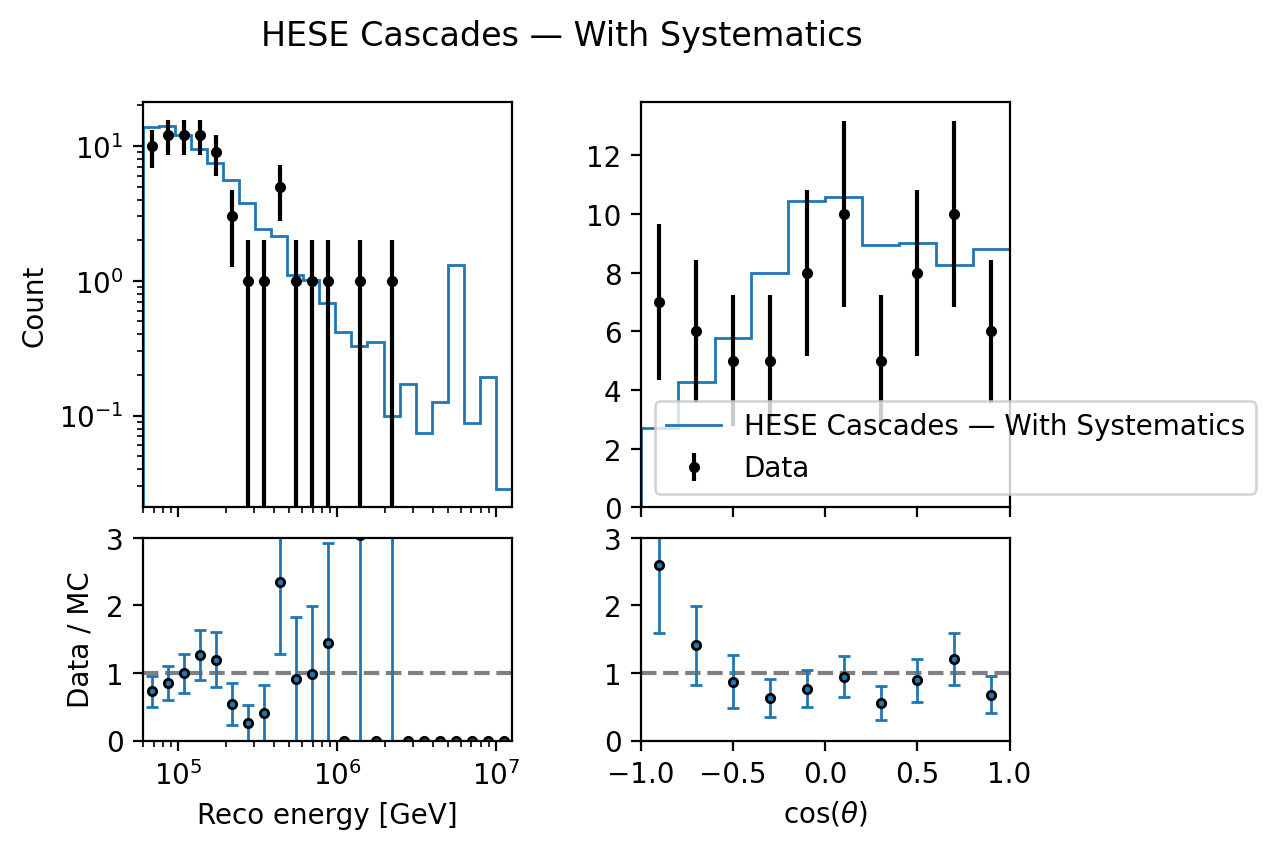

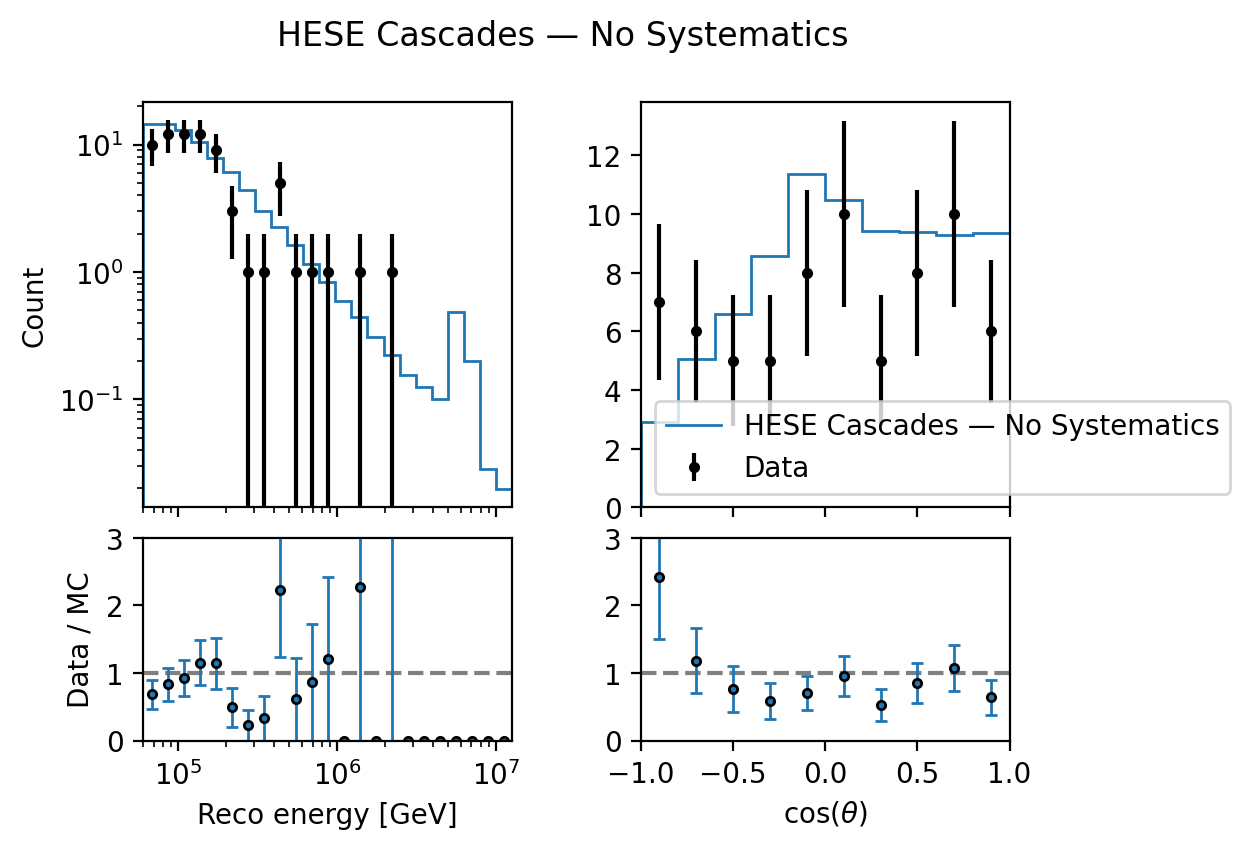

In [8]:
color_cycle = plt.rcParams['axes.prop_cycle']

for scan_name, label in [
    ("hese_spectrum_bestfit_13year_round3",              "HESE Cascades — With Systematics"),
    ("hese_spectrum_bestfit_13year_round3_NoSystematics", "HESE Cascades — No Systematics"),
]:
    fig, axes = RatioPlot(pad=0.1, vert_pad=0.35).create(ncols=2, dpi=200)
    det_config = "IC86_pass2_SnowStorm_FTP_HESE_Cascades"

    plot_data_points(
        axes, det_config, histogram_collection, scan_name,
        binning_dict=binning_dict, color="black", label="Data",
    )
    plot_mc_and_ratio(
        axes, det_config, histogram_collection, scan_name,
        binning_dict=binning_dict, color=color_cycle.by_key()['color'][0],
        hist_label=label, ratio_label="",
    )

    axes[0][1].legend()
    axes[0][0].set_xscale("log")
    axes[0][0].set_yscale("log")
    axes[0][0].set_ylabel("Count")
    axes[0][0].set_xlim(
        binning_dict[det_config]["reco_energy"].min(),
        binning_dict[det_config]["reco_energy"].max(),
    )
    axes[1][0].set_ylabel("Data / MC")
    axes[1][0].set_ylim(0.0, 3.0)
    axes[1][0].set_xlabel("Reco energy [GeV]")
    axes[1][0].axhline(1, color="grey", linestyle="--", zorder=-10)

    axes[0][1].set_xlim(-1, 1.0)
    axes[1][1].set_ylim(0.0, 3.0)
    axes[1][1].axhline(1, color="grey", linestyle="--", zorder=-10)
    axes[1][1].set_xlabel(r"$\cos(\theta)$")

    fig.suptitle(label)
    plt.savefig(os.path.join(save_path, f"{det_config}_{scan_name}.png"), bbox_inches="tight")
    plt.show()


### Tracks Plots

/tmp/ipykernel_747697/329505964.py:47: RuntimeWarning: invalid value encountered in divide
  (err_numerator / numerator)**2 + (err_denominator / denominator)**2


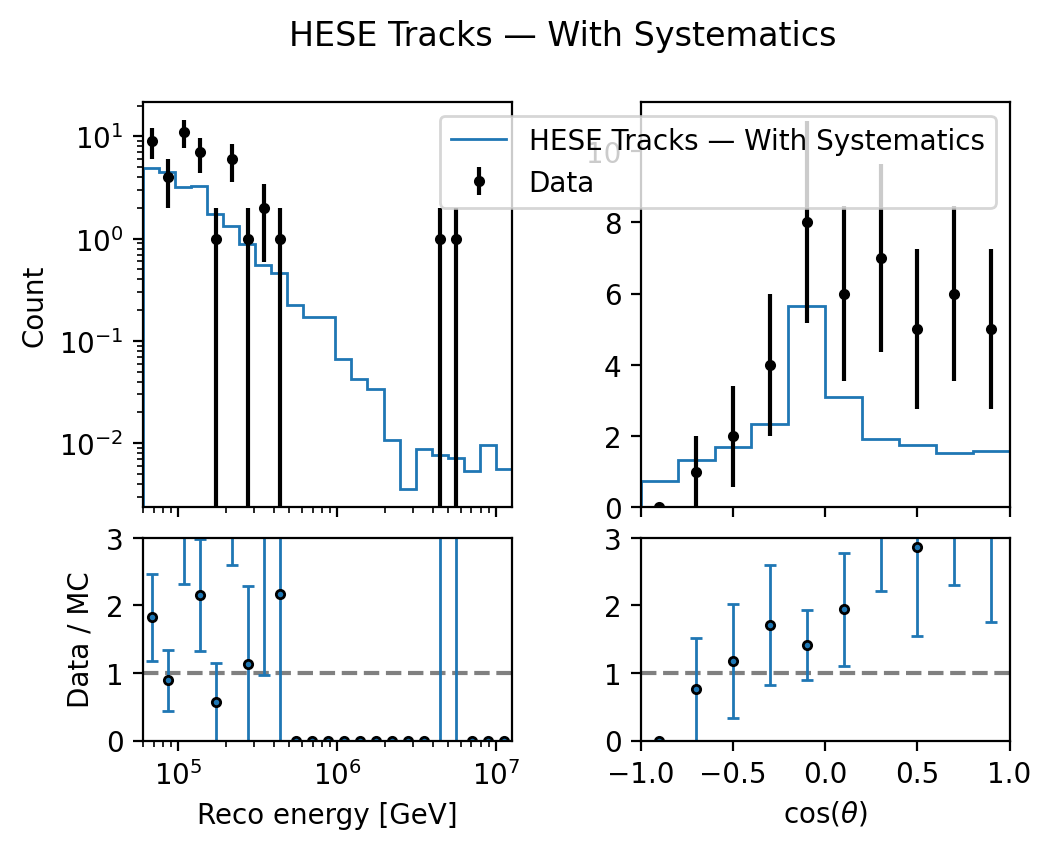

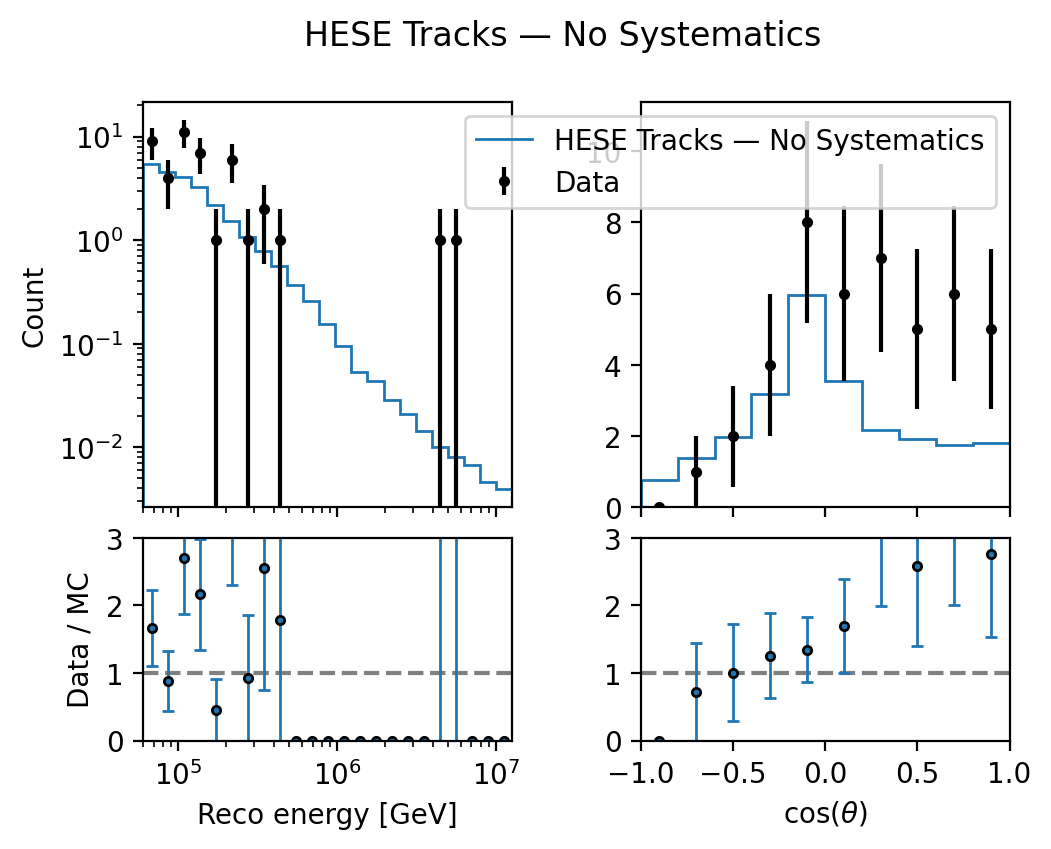

In [9]:
color_cycle = plt.rcParams['axes.prop_cycle']

for scan_name, label in [
    ("hese_spectrum_bestfit_13year_round3",              "HESE Tracks — With Systematics"),
    ("hese_spectrum_bestfit_13year_round3_NoSystematics", "HESE Tracks — No Systematics"),
]:
    fig, axes = RatioPlot(pad=0.1, vert_pad=0.35).create(ncols=2, dpi=200)
    det_config = "IC86_pass2_SnowStorm_FTP_HESE_Tracks"

    plot_data_points(
        axes, det_config, histogram_collection, scan_name,
        binning_dict=binning_dict, color="black", label="Data",
    )
    plot_mc_and_ratio(
        axes, det_config, histogram_collection, scan_name,
        binning_dict=binning_dict, color=color_cycle.by_key()['color'][0],
        hist_label=label, ratio_label="",
    )

    axes[0][1].legend()
    axes[0][0].set_xscale("log")
    axes[0][0].set_yscale("log")
    axes[0][0].set_ylabel("Count")
    axes[0][0].set_xlim(
        binning_dict[det_config]["reco_energy"].min(),
        binning_dict[det_config]["reco_energy"].max(),
    )
    axes[1][0].set_ylabel("Data / MC")
    axes[1][0].set_ylim(0.0, 3.0)
    axes[1][0].set_xlabel("Reco energy [GeV]")
    axes[1][0].axhline(1, color="grey", linestyle="--", zorder=-10)

    axes[0][1].set_xlim(-1, 1.0)
    axes[1][1].set_ylim(0.0, 3.0)
    axes[1][1].axhline(1, color="grey", linestyle="--", zorder=-10)
    axes[1][1].set_xlabel(r"$\cos(\theta)$")

    fig.suptitle(label)
    plt.savefig(os.path.join(save_path, f"{det_config}_{scan_name}.png"), bbox_inches="tight")
    plt.show()
